In [1]:
import pandas as pd
from SCPIntModel import *

In [2]:
import scanpy as sc

In [3]:
multibatch_ann = sc.read_h5ad('../data/task_data/three_tech_ann.h5ad')

In [4]:
multibatch_ann

AnnData object with n_obs × n_vars = 5883 × 797
    obs: 'cluster', 'celltype', 'tech', 'batch'
    uns: 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'

In [5]:
processor = AnnDataProcessor(multibatch_ann, batch_key="batch")

Loaded 5883 cells × 797 proteins
Batches (5): ['SCoPE2-1', 'SCoPE2-2', 'SCoPE2-3', 'pSCoPE', 'plexDIA']


In [6]:
loader  = processor.make_dataloader(batch_size=128)

In [7]:
 # 构建模型
model = scProteoIntegrator(
    n_genes   = processor.n_genes,
    n_batches = processor.n_batches,
)

In [8]:
lambda_cls=0.1
lambda_adv=0.3
lambda_mse=0.5
lr = 0.01
epochs = 1000
warmup = 1
md = 'three_tech'

In [9]:
trainer = Trainer(model, lr=lr, lambda_cls=lambda_cls, lambda_adv=lambda_adv,lambda_mse=lambda_mse, lr_reduc_factor=0.9)

In [10]:
trainer.fit(loader, n_epochs=epochs, adv_warmup_epochs=warmup)

Epoch   10 | total=15.9231 | recon=1.3307 | mse=0.8812 | cls=0.3901 | adv=47.0427 |lr=0.009000000000000001
Epoch   20 | total=7.8012 | recon=1.2980 | mse=0.8525 | cls=0.1746 | adv=20.1986 |lr=0.008100000000000001
Epoch   30 | total=4.1063 | recon=1.3131 | mse=0.8654 | cls=0.2988 | adv=7.7688 |lr=0.006561000000000002
Epoch   40 | total=3.2091 | recon=1.2587 | mse=0.8118 | cls=0.0121 | adv=5.1445 |lr=0.005904900000000002
Epoch   50 | total=4.6858 | recon=1.2537 | mse=0.8100 | cls=0.5326 | adv=9.9129 |lr=0.005314410000000002
Epoch   60 | total=13.6391 | recon=1.2845 | mse=0.8371 | cls=0.7447 | adv=39.5387 |lr=0.004304672100000002
Epoch   70 | total=2.8668 | recon=1.2363 | mse=0.7877 | cls=0.0169 | adv=4.1165 |lr=0.003874204890000002
Epoch   80 | total=6.4458 | recon=1.2010 | mse=0.7628 | cls=0.0190 | adv=16.2050 |lr=0.003874204890000002
Epoch   90 | total=4.6518 | recon=1.2013 | mse=0.7709 | cls=0.0700 | adv=10.1933 |lr=0.003138105960900002
Epoch  100 | total=7.9226 | recon=1.2246 | mse=0

In [11]:
model_name = f"{md}_cls-{lambda_cls}_adv-{lambda_adv}_mse-{lambda_mse}_warmup-{warmup}_lr-{lr}_epoch-{epochs}"

损失曲线已保存至: ../data/model/three_tech_cls-0.1_adv-0.3_mse-0.5_warmup-1_lr-0.01_epoch-1000.svg


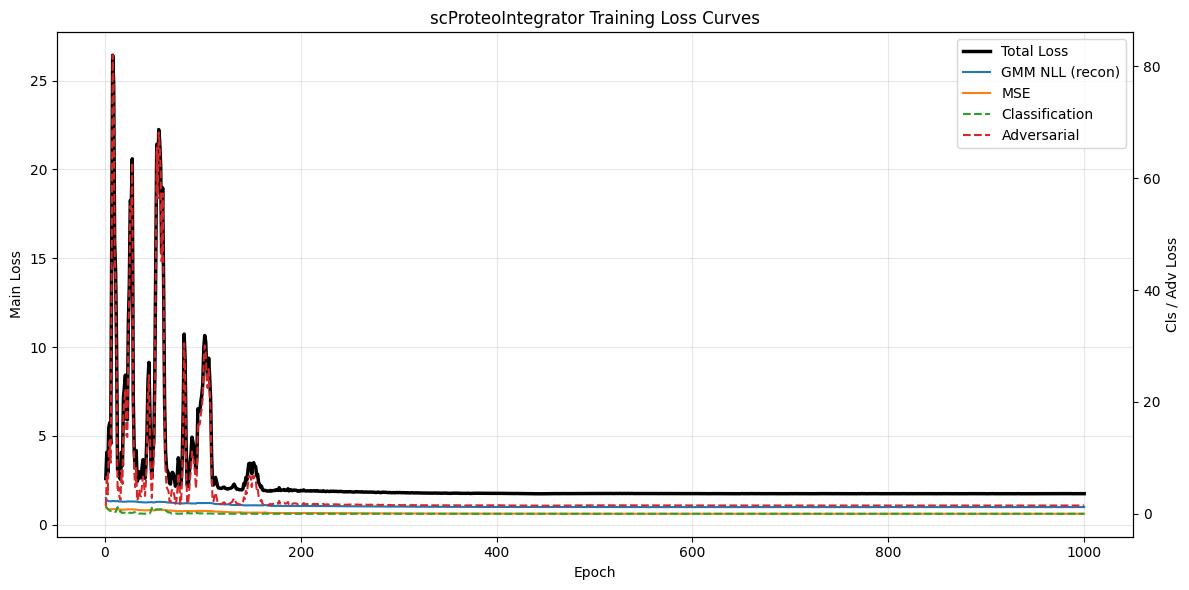

In [12]:
trainer.plot_losses(
    save_path=f"../data/model/{model_name}.svg",   # 可改成任意路径
    show=True                      # False 则只保存不弹窗
)

In [13]:
trainer.save(f"../data/model/{model_name}.pt")

Model saved to ../data/model/three_tech_cls-0.1_adv-0.3_mse-0.5_warmup-1_lr-0.01_epoch-1000.pt
